## Importando as dependências

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn: Tabular e Utilitários
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Sktime: O "Bake-off" de Séries Temporais
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sktime.classification.kernel_based import Arsenal
from sktime.classification.dictionary_based import ContractableBOSS
from sktime.classification.feature_based import Catch22Classifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.classification.shapelet_based import ShapeletTransformClassifier

# Métricas de avaliação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, multilabel_confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

## Importando o dataset

In [2]:
raw_csv_data = pd.read_csv('time_series.csv') 
df = raw_csv_data.copy() 

df_filtered = df[df['afftype'] != 'bipolar I'].copy()

In [3]:
df.head()

,id,timestamp,date,activity,owner,afftype,binary_class
0,0,2003-05-08 00:00:00,2003-05-08,0,condition_1,unipolar depressive,depressed
1,0,2003-05-08 00:01:00,2003-05-08,0,condition_1,unipolar depressive,depressed
2,0,2003-05-08 00:02:00,2003-05-08,0,condition_1,unipolar depressive,depressed
3,0,2003-05-08 00:03:00,2003-05-08,0,condition_1,unipolar depressive,depressed
4,0,2003-05-08 00:04:00,2003-05-08,0,condition_1,unipolar depressive,depressed


In [4]:
X = df_filtered['activity'].values.reshape(-1, 1440)

results_df = df_filtered.iloc[::1440][['owner', 'afftype', 'binary_class', 'date']].reset_index(drop=True)
y = results_df['binary_class'].map({'depressed': 1, 'nondepressed': 0}).values

print(f'Formato da Matriz de Características (X): {X.shape}')
print(f'Formato do Vetor de Rótulos (y): {y.shape}')
print(f'Amostras Depressivas: {sum(y == 1)} | Controles: {sum(y == 0)}')

Formato da Matriz de Características (X): (1015, 1440)
Formato do Vetor de Rótulos (y): (1015,)
Amostras Depressivas: 345 | Controles: 670


## Funções auxiliares

In [5]:
def extract_tabular_features(X_data):
    """Extrai média, desvio padrão e proporção de zeros (Baseline do artigo original)."""
    means = np.mean(X_data, axis=1).reshape(-1, 1)
    stds = np.std(X_data, axis=1).reshape(-1, 1)
    zeros = (np.sum(X_data == 0, axis=1) / 1440).reshape(-1, 1)
    return np.hstack((means, stds, zeros))

In [6]:
def specificity_score(y_test, y_pred):
    global classes
    mcm = multilabel_confusion_matrix(y_test, y_pred, labels=classes)
    specificity_per_class = []
    weights_per_class = []
    for i in range(len(mcm)):
        tn, fp, fn, tp = mcm[i].ravel()
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
        weights_per_class.append(fn + tp)
    return specificity_per_class, weights_per_class

In [7]:
def evaluate_classifier(y_test, y_pred, classes, print_result=False):
    metrics = {}
    
    # Cálculo das métricas para cada classe individualmente
    for cls in classes:
        cls_metrics = {}
        y_test_bin = (y_test == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)

        cls_metrics['Precision'] = precision_score(y_test_bin, y_pred_bin, zero_division=0)
        cls_metrics['Recall'] = recall_score(y_test_bin, y_pred_bin, zero_division=0)
        cls_metrics['Accuracy'] = accuracy_score(y_test_bin, y_pred_bin)
        cls_metrics['MCC'] = matthews_corrcoef(y_test_bin, y_pred_bin)
        cls_metrics['F1-Score'] = f1_score(y_test_bin, y_pred_bin, zero_division=0)
        
        metrics[cls] = cls_metrics
    
    # Cálculo das métricas com média ponderada (weighted average)
    weighted_metrics = {}
    weighted_metrics['Precision'] = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_metrics['Recall'] = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_metrics['F1-Score'] = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_metrics['Accuracy'] = accuracy_score(y_test, y_pred)
    weighted_metrics['MCC'] = matthews_corrcoef(y_test, y_pred)
    
    # Cálculo da Especificidade
    specificity_per_class, weights_per_class = specificity_score(y_test, y_pred)
    for i, cls in enumerate(classes):
        metrics[cls]['Specificity'] = specificity_per_class[i]
    weighted_metrics['Specificity'] = np.average(specificity_per_class, weights=weights_per_class)
    
    metrics['weighted average'] = weighted_metrics
    
    # Exibindo as métricas no console
    if print_result:
        for cls, cls_metrics in metrics.items():
            print(f"Class {cls}:")
            for metric_name, value in cls_metrics.items():
                print(f"  {metric_name}: {value:.5f}")
            print()

    return metrics

In [8]:
def calculate_mean_metrics(metrics_list, classes):
    mean_metrics = {cls: {key: np.mean([fold_metrics[cls][key] for fold_metrics in metrics_list]) for key in metrics_list[0][cls]} for cls in classes}
    return mean_metrics

In [9]:
def organize_metrics(metrics, classes):
    rows = []
    for classifier, metric_list in metrics.items():
        mean_metrics = calculate_mean_metrics(metric_list, classes)
        for subclass in metric_list[0].keys():
            rows.append((classifier, subclass, mean_metrics[subclass]))
    metrics_df = pd.DataFrame([row[2] for row in rows], index=pd.MultiIndex.from_tuples([(row[0], row[1]) for row in rows], names=['Classifier', 'Subclass']))
    return metrics_df

In [10]:
from IPython.display import display, HTML

def display_side_by_side(dfs:list, captions:list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += "\xa0\xa0\xa0"
    display(HTML(output))

In [11]:
ref_model = 'pred_tsf'

def categorize_confusion_matriz(row):
    groun_truth = 1 if row['binary_class'] == 'Depressão' else 0
    y_pred = row[ref_model]
    if groun_truth == 1 and y_pred == 1: return 'TP (Acerto Depressão)'
    if groun_truth == 1 and y_pred == 0: return 'FN (Ignorou Depressão)'
    if groun_truth == 0 and y_pred == 0: return 'TN (Acerto Saudável)'
    if groun_truth == 0 and y_pred == 1: return 'FP (Falso Alarme)'

# Classificação binária ('depressed' vs 'nondepressed')

## Executando os algoritmos

In [ ]:
models = ['svm_tabular', 'tsf', 'arsenal', 'catch22', 'cboss', 'knn_dtw']

for m in models:
    results_df[f'pred_{m}'] = np.nan

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
count = 0

for train_index, test_index in cv.split(X, y):
    count += 1
    print(f'\n--- Iniciando Fold {count}/10 ---')
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # -------------------------------------------------------------
    # PREPARAÇÃO DA ESCALA
    # -------------------------------------------------------------
    scaler_ts = MinMaxScaler()
    X_train_flat = X_train.reshape(-1, 1)
    scaler_ts.fit(X_train_flat) 
    
    X_train_ts = scaler_ts.transform(X_train_flat).reshape(X_train.shape[0], 1, 1440)
    X_test_ts = scaler_ts.transform(X_test.reshape(-1, 1)).reshape(X_test.shape[0], 1, 1440)
    
    X_train_tab = extract_tabular_features(X_train)
    X_test_tab = extract_tabular_features(X_test)
    
    scaler_tab = MinMaxScaler()
    X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
    X_test_tab_scaled = scaler_tab.transform(X_test_tab)
    
    # -------------------------------------------------------------
    # TREINAMENTO E PREDIÇÃO POR CATEGORIA (Bake-off)
    # -------------------------------------------------------------
    
    # 1. TABULAR
    print("Treinando Linear SVM...")
    svm = LinearSVC(class_weight='balanced', random_state=42)
    svm.fit(X_train_tab_scaled, y_train)
    results_df.loc[test_index, 'pred_svm_tabular'] = svm.predict(X_test_tab_scaled)
    
    # 2. INTERVAL-BASED
    print("Treinando Time Series Forest...")
    tsf = TimeSeriesForestClassifier(random_state=42)
    tsf.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_tsf'] = tsf.predict(X_test_ts)
    
    # 3. KERNEL-BASED
    print("Treinando Arsenal...")
    arsenal = Arsenal(random_state=42)
    arsenal.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_arsenal'] = arsenal.predict(X_test_ts)
    
    # 4. FEATURE-BASED
    print("Treinando Catch22...")
    # O Catch22Classifier por padrão usa um RandomForest internamente no sktime
    # Passamos o estimator customizado para usar o class_weight='balanced'
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    catch22 = Catch22Classifier(random_state=42)
    catch22.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_catch22'] = catch22.predict(X_test_ts)

    # 5. DICTIONARY-BASED
    print("Treinando ContractableBOSS...")
    boss = ContractableBOSS(random_state=42)
    boss.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_cboss'] = boss.predict(X_test_ts)

    # 6. DISTANCE-BASED
    print("Treinando KNN com DTW...")
    knn = KNeighborsTimeSeriesClassifier()
    knn.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_knn_dtw'] = knn.predict(X_test_ts)

print("\nBake-off Concluído com Sucesso!")


--- Iniciando Fold 1/10 ---
Treinando Linear SVM...
Treinando Time Series Forest...
Treinando Arsenal...
Treinando Catch22...
Treinando ContractableBOSS...
Treinando KNN com DTW...

--- Iniciando Fold 2/10 ---
Treinando Linear SVM...
Treinando Time Series Forest...
Treinando Arsenal...
Treinando Catch22...
Treinando ContractableBOSS...
Treinando KNN com DTW...

--- Iniciando Fold 3/10 ---
Treinando Linear SVM...
Treinando Time Series Forest...
Treinando Arsenal...
Treinando Catch22...
Treinando ContractableBOSS...
Treinando KNN com DTW...

--- Iniciando Fold 4/10 ---
Treinando Linear SVM...
Treinando Time Series Forest...
Treinando Arsenal...
Treinando Catch22...
Treinando ContractableBOSS...
Treinando KNN com DTW...

--- Iniciando Fold 5/10 ---
Treinando Linear SVM...
Treinando Time Series Forest...
Treinando Arsenal...
Treinando Catch22...
Treinando ContractableBOSS...
Treinando KNN com DTW...

--- Iniciando Fold 6/10 ---
Treinando Linear SVM...
Treinando Time Series Forest...
Trein

In [ ]:
# Novo modelo (número ímpar de classificadores)
# ISTO FOI EXECUTADO APÓS A PRIMEIRA EXECUÇÃO
# raw_csv_data = pd.read_csv('results.csv') 
# results_df = raw_csv_data.copy() 
# results_df.drop(columns=['Unnamed: 0'], inplace=True)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
count = 0

for train_index, test_index in cv.split(X, y):
    count += 1
    print(f'\n--- Iniciando Fold {count}/10 ---')
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # -------------------------------------------------------------
    # PREPARAÇÃO DA ESCALA
    # -------------------------------------------------------------
    scaler_ts = MinMaxScaler()
    X_train_flat = X_train.reshape(-1, 1)
    scaler_ts.fit(X_train_flat) 
    
    X_train_ts = scaler_ts.transform(X_train_flat).reshape(X_train.shape[0], 1, 1440)
    X_test_ts = scaler_ts.transform(X_test.reshape(-1, 1)).reshape(X_test.shape[0], 1, 1440)

    # -------------------------------------------------------------
    # TREINAMENTO E PREDIÇÃO POR CATEGORIA (Bake-off)
    # -------------------------------------------------------------
    
    # 7. SHAPELET-BASED
    print("Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...")
    shapelet = ShapeletTransformClassifier(transform_limit_in_minutes=30, random_state=42)
    shapelet.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_shapelet'] = shapelet.predict(X_test_ts)
    


--- Iniciando Fold 1/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 2/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 3/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 4/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 5/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 6/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 7/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 8/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 9/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...

--- Iniciando Fold 10/10 ---
Treinando Shapelet Transform Classifier (Busca limitada a 30 min)...


In [15]:
# Treinando Time Series Forest de novo para pegar probabilidade
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
count = 0

for train_index, test_index in cv.split(X, y):
    count += 1
    print(f'\n--- Iniciando Fold {count}/10 ---')
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # -------------------------------------------------------------
    # PREPARAÇÃO DA ESCALA
    # -------------------------------------------------------------
    scaler_ts = MinMaxScaler()
    X_train_flat = X_train.reshape(-1, 1)
    scaler_ts.fit(X_train_flat) 
    
    X_train_ts = scaler_ts.transform(X_train_flat).reshape(X_train.shape[0], 1, 1440)
    X_test_ts = scaler_ts.transform(X_test.reshape(-1, 1)).reshape(X_test.shape[0], 1, 1440)

    # Time Series Forest
    print("Treinando Time Series Forest...")
    tsf = TimeSeriesForestClassifier(random_state=42)
    tsf.fit(X_train_ts, y_train)
    results_df.loc[test_index, 'pred_tsf2'] = tsf.predict(X_test_ts)
    
    idx_depressed = list(tsf.classes_).index(1) if 1 in tsf.classes_ else list(tsf.classes_).index('depressed')
    results_df.loc[test_index, 'pred_tsf_proba'] = tsf.predict_proba(X_test_ts)[:, idx_depressed]


--- Iniciando Fold 1/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 2/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 3/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 4/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 5/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 6/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 7/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 8/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 9/10 ---
Treinando Time Series Forest...

--- Iniciando Fold 10/10 ---
Treinando Time Series Forest...


In [16]:
# Verificação se manteve o seed
print(len(results_df.loc[results_df['pred_tsf'] != results_df['pred_tsf2']]) == 0)

True


## Resultados

In [ ]:
# results_df = pd.read_csv('results.csv').drop(columns=['Unnamed: 0']) # Para carregar os resultados após a primeira execução.

In [13]:
models = ['svm_tabular', 'tsf', 'arsenal', 'catch22', 'cboss', 'knn_dtw', 'shapelet']

reverse_map = {1: 'depressed', 0: 'nondepressed'}
y_true_str = np.array([reverse_map[val] for val in y])

classes = ['depressed', 'nondepressed']

metrics = { m.upper().replace('_', ' '): [] for m in models }

for m in models:
    y_pred_str = np.array([reverse_map[val] for val in results_df[f'pred_{m}']])
    
    metrics[m.upper().replace('_', ' ')].append(evaluate_classifier(y_true_str, y_pred_str, classes))

metrics_df = organize_metrics(metrics, classes + ['weighted average'])

In [14]:
display_side_by_side([metrics_df], ['RESULTS'])

### Consenso de Falha + Essemble

In [15]:
pred_columns = [f'pred_{m}' for m in models]
num_classifiers = len(pred_columns)

prediction_matriz = results_df[pred_columns].values
y_true_matriz = y.reshape(-1, 1)

results_df['number_of_errors'] = (prediction_matriz != y_true_matriz).sum(axis=1)
if 'depressed' in results_df['binary_class'].unique():
    results_df['binary_class'] = results_df['binary_class'].map(({'depressed': 'Depressão', 'nondepressed': 'Controle'})).values

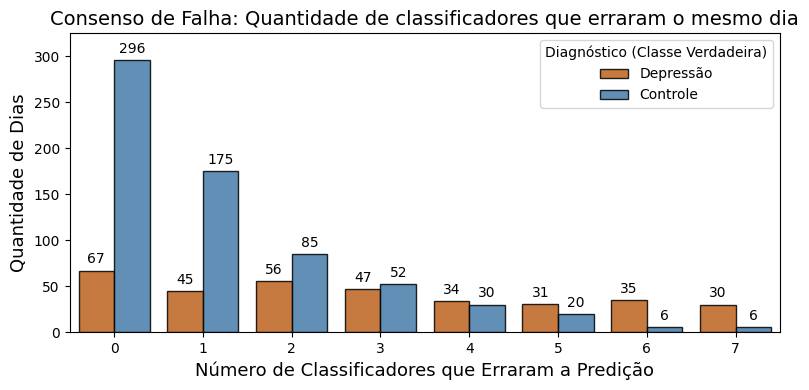

In [16]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=results_df, 
    x='number_of_errors', 
    hue='binary_class',
    palette={'Depressão': '#d95f02', 'Controle': '#377eb8'},
    edgecolor='black',
    alpha=0.85
)

plt.title('Consenso de Falha: Quantidade de classificadores que erraram o mesmo dia', fontsize=14)
plt.xlabel('Número de Classificadores que Erraram a Predição', fontsize=13)
plt.ylabel('Quantidade de Dias', fontsize=13)

plt.legend(title='Diagnóstico (Classe Verdadeira)')
plt.xticks(range(num_classifiers + 1))
plt.ylim(top=325)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [17]:

results_df['pred_ensemble'] = results_df[pred_columns].mode(axis=1).values

y_pred_str = np.array([reverse_map[val] for val in results_df[f'pred_ensemble']])
essemble_metrics= {'Ensemble': [evaluate_classifier(y_true_str, y_pred_str, classes)]}

essemble_metrics_df = organize_metrics(essemble_metrics, classes + ['weighted average'])

In [18]:
display_side_by_side([essemble_metrics_df], ['ENSEMBLE RESULTS'])

In [19]:
print("Erros TSF (Controle):", len(results_df.loc[(results_df['pred_tsf'] != y) & (results_df['binary_class'] == 'Controle')]))
print("Erros TSF (Depressão):", len(results_df.loc[(results_df['pred_tsf'] != y) & (results_df['binary_class'] == 'Depressão')]))
print()
print("Erros Essemble (Controle):", len(results_df.loc[(results_df['pred_ensemble'] != y) & (results_df['binary_class'] == 'Controle')]))
print("Erros Essemble (Depressão):", len(results_df.loc[(results_df['pred_ensemble'] != y) & (results_df['binary_class'] == 'Depressão')]))

Erros TSF (Controle): 82
Erros TSF (Depressão): 118

Erros Essemble (Controle): 62
Erros Essemble (Depressão): 130


### Time Series Forest

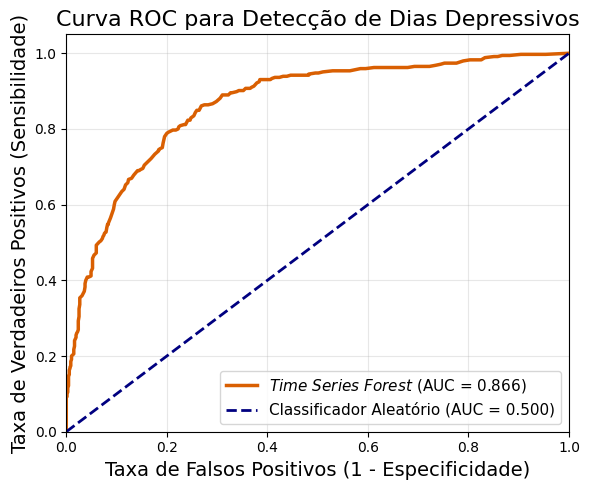

In [21]:
plt.figure(figsize=(6, 5))

y_true_bin = (y_true_str == 'depressed').astype(int)
y_probs_tsf = results_df['pred_tsf_proba'].values

fpr, tpr, thresholds = roc_curve(y_true_bin, y_probs_tsf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='#d95f02', lw=2.5, label=r'$\mathit{Time\ Series\ Forest}$' + f' (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=14)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=14)
plt.title('Curva ROC para Detecção de Dias Depressivos', fontsize=16)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

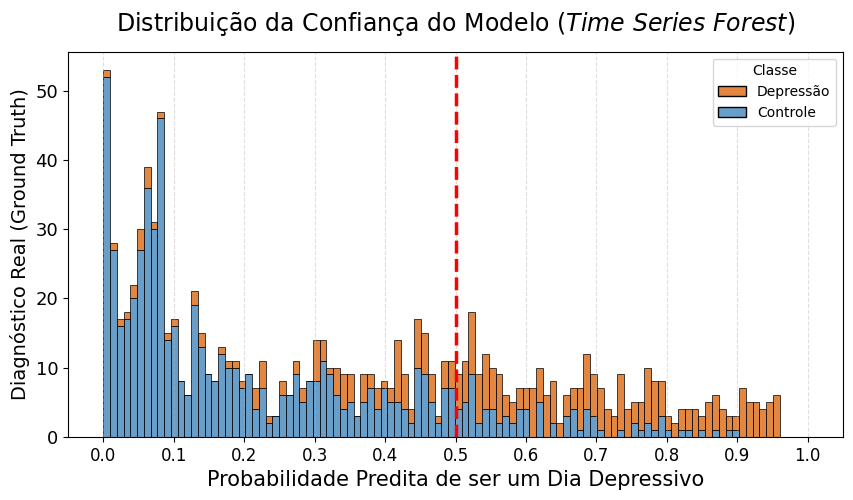

In [22]:
plt.figure(figsize=(10, 5))

results_df['Classe'] = results_df['binary_class']
ax = sns.histplot(
    data=results_df,
    x='pred_tsf_proba',
    hue='Classe',
    palette={'Depressão': '#d95f02', 'Controle': '#377eb8'}, 
    bins=100,
    multiple='stack'
)

plt.title(r'Distribuição da Confiança do Modelo ($\mathit{Time\ Series\ Forest}$)', fontsize=17, pad=15)
plt.xlabel('Probabilidade Predita de ser um Dia Depressivo', fontsize=15)
plt.ylabel('Diagnóstico Real (Ground Truth)', fontsize=14)
plt.xlim(-0.05, 1.05) 
plt.xticks(np.arange(0, 1.1, 0.1), fontsize=12)
plt.yticks(fontsize=13)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2.5)

plt.show()

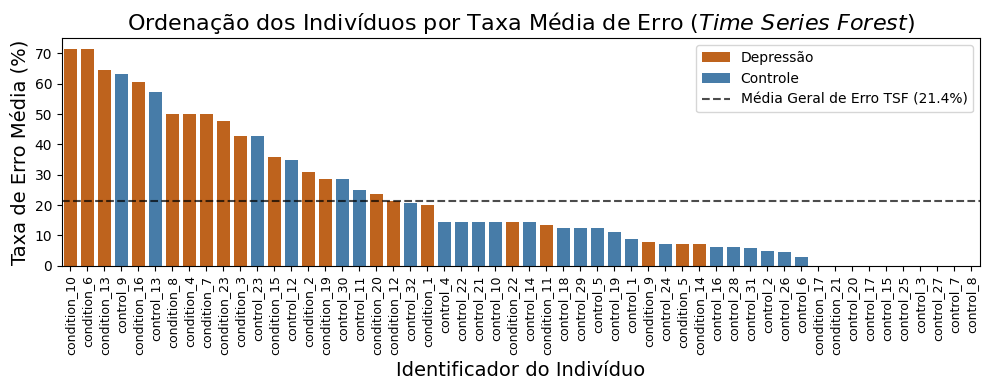

In [24]:
results_df['tsf_error'] = results_df[ref_model] != y
errors_per_person = results_df.groupby('owner')['tsf_error'].agg(['sum', 'count']).reset_index()
errors_per_person.columns = ['owner', 'wrong_days', 'total_days']
errors_per_person['error_rate'] = (errors_per_person['wrong_days'] / errors_per_person['total_days']) * 100

errors_per_person = errors_per_person.sort_values(by='error_rate', ascending=False)

errors_per_person['class'] = np.where(errors_per_person['owner'].str.contains('condition'), 'Depressão', 'Controle')

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=errors_per_person, 
    x='owner', 
    y='error_rate', 
    hue='class', 
    palette={'Depressão': '#d95f02', 'Controle': '#377eb8'},
    dodge=False
)

plt.title(r'Ordenação dos Indivíduos por Taxa Média de Erro ($\mathit{Time\ Series\ Forest}$)', fontsize=16)
plt.xlabel('Identificador do Indivíduo', fontsize=14)
plt.ylabel('Taxa de Erro Média (%)', fontsize=14)

plt.xticks(rotation=90, fontsize=9) 

mean_error = errors_per_person['error_rate'].mean()
#plt.axhline(50, color='red', linestyle='--', alpha=0.7, label=f'Classificador Aleatório')
plt.axhline(mean_error, color='black', linestyle='--', alpha=0.7, label=f'Média Geral de Erro TSF ({mean_error:.1f}%)')

plt.legend()
plt.tight_layout()
plt.show()

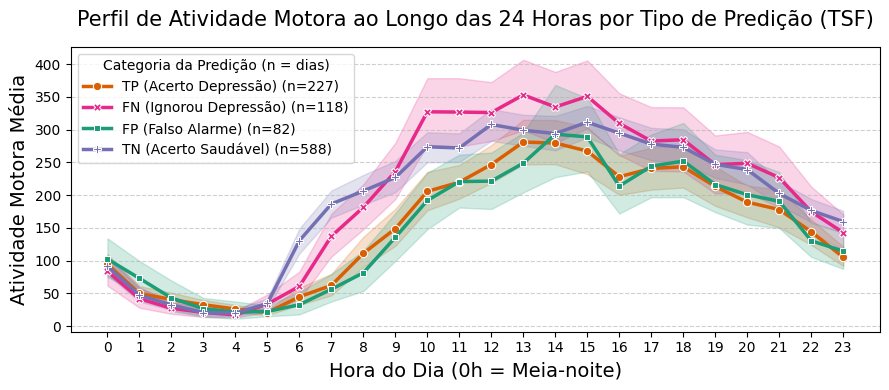

In [31]:
results_df['result_type'] = results_df.apply(categorize_confusion_matriz, axis=1)

counts = results_df['result_type'].value_counts().to_dict()

X_hourly_mean = X.reshape(X.shape[0], 24, 60).mean(axis=2)
hourly_df = pd.DataFrame(X_hourly_mean, columns=[f'hour_{i}' for i in range(24)])
hourly_df['result_type'] = results_df['result_type'].map(lambda x: f"{x} (n={counts[x]})")

hourly_melted = hourly_df.melt(id_vars=['result_type'], var_name='hour', value_name='motor_activity')
hourly_melted['hour'] = hourly_melted['hour'].str.replace('hour_', '').astype(int)

plt.figure(figsize=(9, 4))
sns.lineplot(
    data=hourly_melted, 
    x='hour', 
    y='motor_activity', 
    hue='result_type', 
    style='result_type', 
    markers=True, 
    dashes=False, 
    linewidth=2.5,
    palette=['#d95f02', '#e7298a', '#1b9e77', '#7570b3']
)

plt.title('Perfil de Atividade Motora ao Longo das 24 Horas por Tipo de Predição (TSF)', fontsize=15, pad=15)
plt.xlabel('Hora do Dia (0h = Meia-noite)', fontsize=14)
plt.ylabel('Atividade Motora Média', fontsize=14)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Categoria da Predição (n = dias)')

plt.tight_layout()
plt.show()

In [28]:
results_df.to_csv('results.csv')

In [15]:
results_df

,owner,afftype,binary_class,date,pred_svm_tabular,pred_tsf,pred_arsenal,pred_catch22,pred_knn_dtw,pred_cboss,number_of_errors,tsf_error,result_type,pred_shapelet,pred_tsf2,pred_tsf_proba,pred_ensemble
0,condition_1,unipolar depressive,Depressão,2003-05-08,0.0,1.0,1.0,1.0,1.0,1.0,1,False,TP (Acerto Depressão),1.0,1.0,0.590000,1.0
1,condition_1,unipolar depressive,Depressão,2003-05-09,1.0,1.0,1.0,1.0,0.0,1.0,1,False,TP (Acerto Depressão),1.0,1.0,0.730000,1.0
2,condition_1,unipolar depressive,Depressão,2003-05-10,1.0,0.0,1.0,1.0,1.0,0.0,2,True,FN (Ignorou Depressão),1.0,0.0,0.500000,1.0
3,condition_1,unipolar depressive,Depressão,2003-05-11,1.0,1.0,1.0,1.0,1.0,0.0,1,False,TP (Acerto Depressão),1.0,1.0,0.885000,1.0
4,condition_1,unipolar depressive,Depressão,2003-05-12,1.0,1.0,1.0,1.0,1.0,1.0,0,False,TP (Acerto Depressão),1.0,1.0,0.590000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,control_32,control,Controle,2003-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0,False,TN (Acerto Saudável),0.0,0.0,0.063708,0.0
1011,control_32,control,Controle,2003-04-19,0.0,0.0,0.0,0.0,0.0,0.0,0,False,TN (Acerto Saudável),0.0,0.0,0.063708,0.0
1012,control_32,control,Controle,2003-04-20,0.0,0.0,0.0,0.0,0.0,0.0,0,False,TN (Acerto Saudável),0.0,0.0,0.079635,0.0
1013,control_32,control,Controle,2003-04-21,0.0,0.0,0.0,0.0,0.0,0.0,0,False,TN (Acerto Saudável),0.0,0.0,0.079635,0.0
